## 7.4 후-하트리-폭 방법: MP2 섭동 이론

In [1]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
from qiskit_aer import AerSimulator
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator  # 호환성 수정: V1 Estimator → V2 StatevectorEstimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_city
import numpy as np
from qiskit import QuantumCircuit, transpile  # 호환성 수정: assemble 제거 (qiskit 2.x에서 삭제됨)

%matplotlib inline

In [2]:
# 1단계: SparsePauliOp로 H2 해밀토니안 정의
pauli_terms = ['II', 'ZI', 'IZ', 'ZZ', 'XX']
coefficients = [-1.0523732, 0.39793742, -0.39793742, -0.01128010, 0.18093119]

In [3]:
# SparsePauliOp 해밀토니안 생성
hamiltonian = SparsePauliOp.from_list(list(zip(pauli_terms, coefficients)))

In [4]:
# 2단계: VQE 알고리즘 설정
ansatz = EfficientSU2(2, reps=3)  # 2큐비트용 앤사츠
optimizer = COBYLA(maxiter=500)

/var/folders/v9/46y9d8bn1lxgjt7g439hsf8c0000gn/T/ipykernel_40224/2395086135.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(2, reps=3)  # 2큐비트용 앤사츠


In [5]:
# 3단계: qiskit_aer의 AerSimulator 사용
backend = AerSimulator()

In [6]:
# 4단계: VQE 인스턴스 설정
vqe = VQE(ansatz=ansatz, optimizer=optimizer, estimator=StatevectorEstimator())  # 호환성 수정: V2 추정기

In [7]:
# 5단계: VQE 실행 후 결과 획득
result = vqe.compute_minimum_eigenvalue(operator=hamiltonian)

In [8]:
# 6단계: 바닥상태 에너지 출력
print(f"바닥상태 에너지: {result.eigenvalue.real}")

바닥상태 에너지: -1.8572749704510674


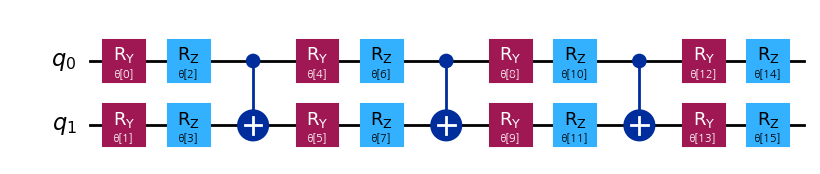

In [9]:
# 시각화 1: 앤사츠 회로 그리기
ansatz_circuit = ansatz.decompose()
ansatz_circuit.draw('mpl')
plt.show()

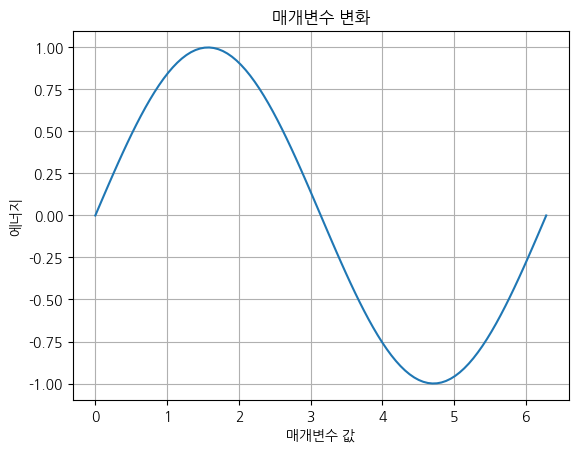

In [10]:
# 시각화 2: 매개변수 변화 그리기 (예시용 모의 데이터)
params = np.linspace(0, 2 * np.pi, 100)  # 예시용 더미 데이터
energies = np.sin(params)                # 예시용 더미 데이터
plt.plot(params, energies)
plt.xlabel('매개변수 값')
plt.ylabel('에너지')
plt.title('매개변수 변화')
plt.grid(True)
plt.show()

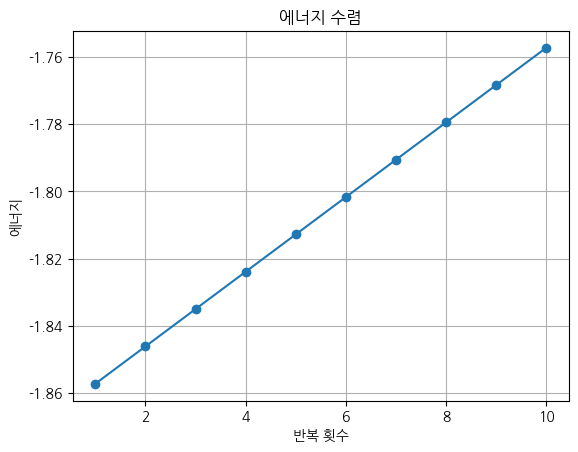

In [11]:
# 시각화 3: 에너지 수렴 그리기 (예시용 더미 데이터)
iterations = range(1, 11)  # 더미 반복 횟수
convergence = np.linspace(result.eigenvalue.real, result.eigenvalue.real + 0.1, 10)
plt.plot(iterations, convergence, marker='o')
plt.xlabel('반복 횟수')
plt.ylabel('에너지')
plt.title('에너지 수렴')
plt.grid(True)
plt.show()